---
title: Searching on a Custom Metric
image: image.png
toc: true
execute:
  enabled: true
---

Every combination that `solve()` evaluates already computes the *whole* metric set -- average travel time, the 90th percentile, the maximum, coverage, equity ratios, and (once you pass a `baseline=`) how many people end up better or worse off. Historically, though, only a handful of those columns could ever *decide* which combination won, and you chose between them indirectly, by picking an `objectives` model.

`solve(rank_on=...)` lets the search itself optimise any scalar metric it computes.

This example works through what that changes, using the 15 minor injury units (MIUs) in Devon. First on a "which sites would we open" question, comparing the default average travel time against a metric that was previously unreachable -- the 90th percentile journey. Then on a two-site closure problem, where the metric you rank on turns out to change *who* bears the cost far more than it changes the headline number.

## Setting up the problem

This is the same Devon MIU setup as [site closure problems](../site_closures/index.ipynb), except that here we use the **car** travel matrix rather than the public transport one, so the journey times below look more familiar.

We register IMD (Index of Multiple Deprivation) decile via `add_equity_data()`, with `disadvantaged_end="low"` since decile 1 is the most deprived 10% of LSOAs -- the same source used in [population impact vs baseline](../population_impact/index.ipynb). Here it does more than unlock a breakdown: it makes `inter_tertile_ratio` available, and later in this example we rank on it directly.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="MF50-84",
    location_id_col="LSOA 2021 Name",
    )

problem.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name",
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM",
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD decile",
    disadvantaged_end="low",
    )

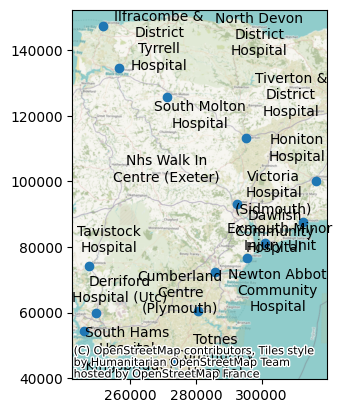

In [2]:
problem.plot_sites()

## Part 1: the same question, two different metrics

Let's imagine a scenario where only three of these fifteen units can stay staffed around the clock, and we want to know which three.

We'll start with the default: `objectives="p_median"`, which ranks combinations by `weighted_average` -- the demand-weighted mean travel time across the whole region. With 15 candidate sites and `p=3` there are only 455 combinations, so we can brute-force every one of them.

In [3]:
import pandas as pd

comparison_cols = ["solution_rank", "site_names", "weighted_average", "90th_percentile", "max"]

solution_weighted_average = problem.solve(
    p=3,
    threshold_for_coverage=30,
    )

solution_weighted_average.show_solutions(n_best=3)[comparison_cols]

  0%|          | 0/455 [00:00<?, ?it/s]

,solution_rank,site_names,weighted_average,90th_percentile,max
0,1,"[North Devon District Hospital, NHS Walk in Ce...",26.46,42.0,64.0
1,2,"[North Devon District Hospital, Totnes Communi...",26.82,38.0,64.0
2,3,"[North Devon District Hospital, Newton Abbot C...",26.96,44.8,64.0


So the best three sites on average travel time are North Devon District Hospital, the NHS Walk in Centre in Exeter, and Derriford Hospital in Plymouth -- one large urban centre each in the north, the middle and the south-west, which is very much what a demand-weighted average is designed to find.

Look at the `90th_percentile` column, though. The average journey is 26.5 minutes, but the *worst-served tenth* of the population is travelling 42 minutes or more. An average over a county with Devon's geography quietly balances a lot of city-dwellers who live minutes from a site against a smaller rural population who don't.

Suppose the question we were actually asked is "what does this look like for the people it works worst for?" That makes the 90th percentile the metric we want to *choose* on -- not just report.

### Ranking on the 90th percentile

`rank_on` takes the name of any scalar column `solve()` computes. Everything else about the problem stays the same -- same candidate sites, same `p`, same brute-force search over the same 455 combinations. The only thing that changes is which column decides the winner.

In [4]:
solution_90th = problem.solve(
    p=3,
    threshold_for_coverage=30,
    rank_on="90th_percentile",
    )

solution_90th.show_solutions(n_best=3)[comparison_cols]

  0%|          | 0/455 [00:00<?, ?it/s]

,solution_rank,site_names,weighted_average,90th_percentile,max
0,1,"[North Devon District Hospital, Totnes Communi...",26.82,38.0,64.0
1,2,"[North Devon District Hospital, Honiton Hospit...",28.30,38.0,72.0
2,3,"[Totnes Community Hospital, NHS Walk in Centre...",27.37,39.0,68.0


A different answer. Derriford Hospital (Plymouth) is out; Totnes Community Hospital is in.

That swap is the whole trade-off in miniature. Derriford sits in Devon's largest city, so keeping it open pulls a lot of people's journeys down at once and the demand-weighted average loves it. Totnes serves the rural south of the county, where there are fewer people but much longer drives -- it barely moves the average, and does a great deal for the tail.

In [5]:
best_weighted_average = solution_weighted_average.show_solutions(n_best=1).iloc[0]
best_90th = solution_90th.show_solutions(n_best=1).iloc[0]

pd.DataFrame({
    "Ranked on weighted_average": best_weighted_average[["weighted_average", "90th_percentile", "max"]],
    "Ranked on 90th_percentile": best_90th[["weighted_average", "90th_percentile", "max"]],
    }).assign(Difference=lambda df: df.iloc[:, 1] - df.iloc[:, 0])

,Ranked on weighted_average,Ranked on 90th_percentile,Difference
weighted_average,26.46,26.82,0.36
90th_percentile,42.0,38.0,-4.0
max,64.0,64.0,0.0


Ranking on the 90th percentile costs about a third of a minute on the region-wide average, and buys four minutes off the journey for the worst-served tenth of the population. Whether that's a trade worth making isn't lokigi's call -- but it isn't a trade you can even *see* if the average is the only thing that ever gets to rank a solution.

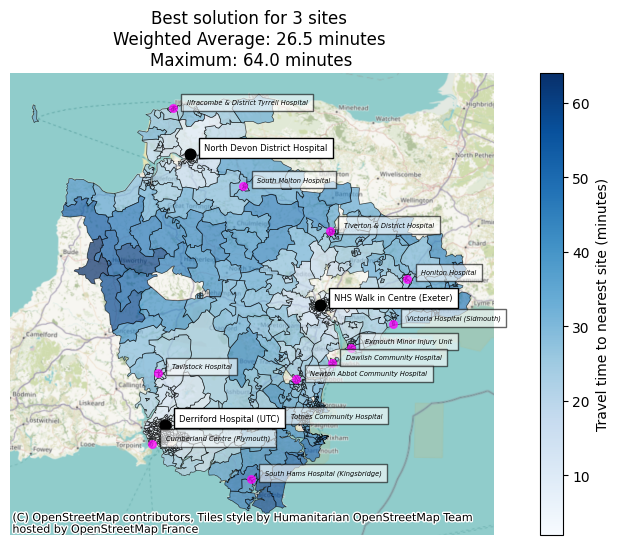

In [6]:
solution_weighted_average.plot_best_combination(
    unchosen_site_colour="magenta",
    label_all_locations=True,
    legend_loc="lower right",
    );

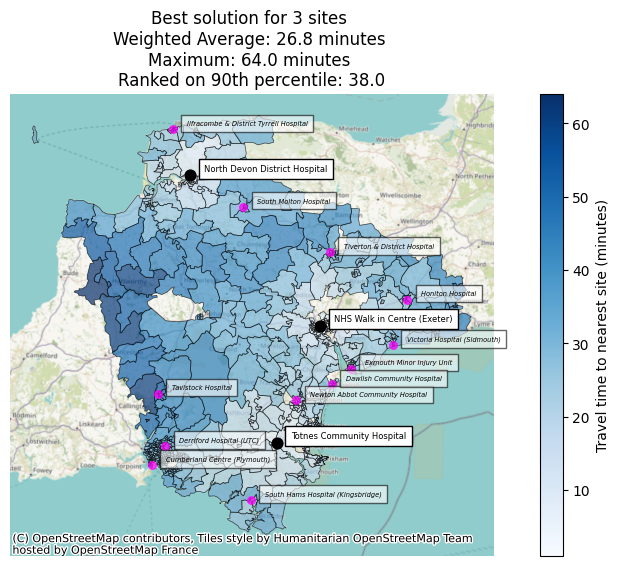

In [7]:
ax = solution_90th.plot_best_combination(
    unchosen_site_colour="magenta",
    label_all_locations=True,
    legend_loc="lower right",
    )
ax.get_figure().savefig("image.png", dpi=150, bbox_inches="tight")

Notice the extra line on the second plot's annotation: when you rank on something other than the objective's own metric, the solution set records that and says so, rather than silently reporting the usual headline figures as though they were what the search optimised.

## "Couldn't I just sort the results afterwards?"

For the run above -- yes, actually. Brute force evaluated all 455 combinations and kept them all, so the best-on-90th-percentile option was sitting in the results the whole time, and `show_solutions()` can be re-sorted to find it.

In [8]:
all_solutions = solution_weighted_average.show_solutions()

all_solutions["90th_percentile_rank"] = all_solutions["90th_percentile"].rank(method="min").astype(int)

all_solutions.sort_values("weighted_average").head(6)[
    ["solution_rank", "90th_percentile_rank", "weighted_average", "90th_percentile", "site_names"]
    ]

,solution_rank,90th_percentile_rank,weighted_average,90th_percentile,site_names
0,1,14,26.46,42.0,"[North Devon District Hospital, NHS Walk in Ce..."
1,2,1,26.82,38.0,"[North Devon District Hospital, Totnes Communi..."
2,3,50,26.96,44.8,"[North Devon District Hospital, Newton Abbot C..."
3,4,14,26.98,42.0,"[Newton Abbot Community Hospital, Derriford Ho..."
4,5,13,27.02,41.8,"[NHS Walk in Centre (Exeter), Derriford Hospit..."
5,6,3,27.37,39.0,"[Totnes Community Hospital, NHS Walk in Centre..."


The winner on average travel time is only the 14th-best of 455 on the 90th percentile, and the option that *is* best on the 90th percentile happens to be sitting at rank 2. Re-sorting finds it fine.

But that only works because nothing was thrown away. Re-sorting can reorder the combinations the search chose to keep -- it cannot recover one the search chose to discard. And as soon as a problem is big enough that you can't keep everything, something is always being discarded.

The clearest illustration is the greedy solver, which builds a solution one site at a time, keeping whichever single site most improves the score at each step. It returns exactly one solution, so there is nothing to re-sort at all.

In [9]:
solution_greedy_default = problem.solve(
    p=3,
    threshold_for_coverage=30,
    search_strategy="greedy",
    )

solution_greedy_rank_on = problem.solve(
    p=3,
    threshold_for_coverage=30,
    search_strategy="greedy",
    rank_on="90th_percentile",
    )

pd.concat([
    solution_greedy_default.show_solutions().assign(ranked_on="weighted_average"),
    solution_greedy_rank_on.show_solutions().assign(ranked_on="90th_percentile"),
    ])[["ranked_on", "site_names", "weighted_average", "90th_percentile"]]

  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [5]


Best combination for 2 sites: [0, 5]


Best combination for 3 sites: [0, 5, 11]


  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [7]


Best combination for 2 sites: [0, 7]


Best combination for 3 sites: [0, 6, 7]


,ranked_on,site_names,weighted_average,90th_percentile
0,weighted_average,"[North Devon District Hospital, Newton Abbot C...",26.96,44.8
0,90th_percentile,"[North Devon District Hospital, Totnes Communi...",26.82,38.0


Greedy ranking on `weighted_average` lands on a combination whose 90th percentile is 44.8 minutes -- the 50th-best of the 455 possible combinations on that measure. Greedy ranking on `90th_percentile` finds 38.0 minutes, which we know from the brute-force run above is the true optimum.

Nearly seven minutes of difference for the worst-served tenth of the county, and no amount of post-hoc sorting could have retrieved it, because the search only ever built one path and it built it towards the wrong target.

The same argument applies to `brute_force_keep_best_n` (which streams through every combination but only retains the best *n* on the ranking metric) and to GRASP (which keeps a pool of good solutions and locally improves them). In all three cases `rank_on` changes what survives, not just what order the survivors are printed in.

:::{.callout-note}
`rank_on` appears in two places in lokigi and they do different things at different moments.

`solve(rank_on=...)` -- used here -- drives the **search**: it decides which combinations win and which are kept.

`show_solutions(sort_by=...)`, `plot_best_combination(sort_by=...)` and friends re-sort a **finished** `SiteSolutionSet`. That's still useful -- [site closure problems](../site_closures/index.ipynb) uses it to view a completed brute-force run through a different lens -- but it's limited to whatever the search already retained.
:::

## How `rank_on` fits alongside `objectives`

It's reasonable to ask why this is a separate argument rather than just another entry in `objectives`. The answer is that `objectives` was doing two jobs at once:

1. **choosing the ranking column** -- `p_median` ranks on `weighted_average`, `p_center` on `max`, `mclp` on coverage; and
2. **applying that model's constraints** -- `hybrid_p_median` discards any combination whose worst journey exceeds `max_value_cutoff`; `mclp` needs a coverage threshold to count against.

`rank_on` takes over the first job only, which leaves the second one composable. So you can keep a model's constraint and still rank the qualifying combinations on whatever you like:

In [10]:
solution_hybrid = problem.solve(
    p=3,
    objectives="hybrid_p_median",
    max_value_cutoff=65,
    rank_on="90th_percentile",
    threshold_for_coverage=30,
    )

print(f"{len(solution_hybrid.show_solutions())} of 455 combinations kept every journey under 65 minutes")

solution_hybrid.show_solutions(n_best=3)[comparison_cols]

  0%|          | 0/455 [00:00<?, ?it/s]

14 of 455 combinations kept every journey under 65 minutes


,solution_rank,site_names,weighted_average,90th_percentile,max
0,1,"[North Devon District Hospital, Totnes Communi...",26.82,38.0,64.0
1,2,"[Newton Abbot Community Hospital, Tavistock Ho...",29.57,41.0,62.0
2,3,"[North Devon District Hospital, NHS Walk in Ce...",26.46,42.0,64.0


That reads as "no one may travel more than 65 minutes, and among the options that manage it, give me the one that's kindest to the worst-served tenth" -- a sentence with a constraint *and* a preference in it, which needs both arguments to express.

### The `custom` objective

Sometimes you don't want a model's constraints at all -- you just want to rank on your metric. Passing `rank_on` to the default `p_median` would technically do that, but it leaves the solution set claiming to be a p-median solve when it isn't, and p-median is a specific, named thing in the location-allocation literature.

`objectives="custom"` is the honest way to say "no textbook model here, rank on what I've told you":

In [11]:
solution_custom = problem.solve(
    p=3,
    objectives="custom",
    rank_on="90th_percentile",
    threshold_for_coverage=30,
    )

solution_custom.show_solutions(n_best=1)[comparison_cols]

  0%|          | 0/455 [00:00<?, ?it/s]

,solution_rank,site_names,weighted_average,90th_percentile,max
0,1,"[North Devon District Hospital, Totnes Communi...",26.82,38.0,64.0


It's the same answer we got earlier -- `p_median` applies no constraints of its own either, so with `rank_on` set the two runs search identically. What differs is what the result *says about itself*, which matters when the solution set is going into a report.

Because `custom` supplies no metric of its own, it can't be used on its own:

In [12]:
try:
    problem.solve(p=3, objectives="custom")
except ValueError as e:
    print(e)

The 'custom' objective requires rank_on=<column name or Metric> -- it applies no model of its own, so the metric to rank on has to come from you. Either pass rank_on, or use a named objective (p_median, hybrid_p_median, p_center, simple_p_median, hybrid_simple_p_median, mclp).


`describe_models()` lists it alongside the named models, with the same honesty about what it does and doesn't guarantee.

In [13]:
problem.describe_models()

=== Supported Healthcare Location Models ===

ID: simple_p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance or time.
When to use: Best for situations like siting a series of storage hubs efficiently across a region where demand/volume doesn't matter.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.

ID: p_median
Name: P-Median (Average Weighted Distance Minimizer)
Goal: Minimize the total travel distance or time for the entire population, weighting the travel times by a metric such as demand per region.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.

ID: hybrid_simple_p_median
Name: Hybrid Simple P-Median (The Safety Net Model)
Goal: Minimize the total travel distance or time, weighting the travel times by a metric 

### Naming a column that won't work

`rank_on` is validated against a single representative combination *before* the search starts, so a mistake costs you a second rather than a full solve. The error tells you what's actually rankable for the problem as you've configured it:

In [14]:
try:
    problem.solve(p=3, rank_on="average_travel_time")
except KeyError as e:
    print(e.args[0])

rank_on='average_travel_time' is not a metric this problem computes. Rankable columns for this problem are: 90th_percentile, avg_lower_third_bins, avg_middle_third_bins, avg_upper_third_bins, demand_unreachable, demand_within_coverage_threshold, gap_absolute_weighted, gap_relative_weighted, inter_tertile_ratio, max, max_for_ranking, proportion_demand_unreachable, proportion_regions_within_coverage_threshold, proportion_within_coverage_threshold, regions_unreachable, regions_within_coverage_threshold, total_cost, unweighted_average, unweighted_average_for_ranking, weighted_average, weighted_average_for_ranking. Call describe_solution_columns() on a previous result for these grouped and explained. Note that some columns only appear once their input is registered -- the population-impact metrics need solve(baseline=...), demand_beyond_threshold_<t> needs beyond_thresholds=, and '<metric>__<label>' needs the matching secondary travel matrix or demand scenario.


Some columns exist but still can't rank anything -- the by-equity-group metrics hold one value *per band* rather than one per solution:

In [15]:
try:
    problem.solve(p=3, rank_on="weighted_by_equity_group")
except ValueError as e:
    print(e)

rank_on='weighted_by_equity_group' holds one value per equity band (a dict of 10 entries), so there is no single number to rank solutions by. Rank on one of the scalar summaries derived from the bands instead -- 'gap_absolute_weighted' (worst band minus best), 'gap_relative_weighted' (worst band over best), or 'inter_tertile_ratio' (most- over least-disadvantaged third) -- or pick a single band out of this column yourself after solving.


### Metrics that are best at neither extreme

A bare string gets its direction from convention: travel times are lower-is-better, coverage and improvement metrics are higher-is-better. That covers most cases, but not all of them.

`inter_tertile_ratio` compares the average journey of the most-deprived third of the population against the least-deprived third. A ratio of 1.0 means the two groups travel the same distance. **Both** directions away from 1.0 are a form of inequity -- 1.3 means the most deprived travel 30% further, and 0.7 means the least deprived do.

So minimising it is wrong and maximising it is wrong (if trying to minimise differences - you may sometimes want to prioritise shorter travel times for the most deprived, but let's imagine here we're just focussed on equity). 

Passing it as a bare string gets you the convention for a ratio -- lower is better -- which here means the search hunts for the most lopsided solution it can find, just lopsided in the direction that happens to be numerically smaller:

In [16]:
solution_equity_naive = problem.solve(
    p=3,
    threshold_for_coverage=30,
    rank_on="inter_tertile_ratio",
    )

solution_equity_naive.show_solutions(n_best=3)[
    ["solution_rank", "inter_tertile_ratio", "inter_tertile_description", "weighted_average"]
    ]

  0%|          | 0/455 [00:00<?, ?it/s]

,solution_rank,inter_tertile_ratio,inter_tertile_description,weighted_average
0,1,0.82,Slightly Progressive (Most deprived travel 18%...,29.66
1,2,0.83,Slightly Progressive (Most deprived travel 17%...,30.13
2,3,0.84,Slightly Progressive (Most deprived travel 16%...,38.48


Across all 455 combinations this ratio runs from 0.82 to 1.63, and the bare-string search has gone straight for the 0.82 end -- a solution where the most deprived third travel 18% *less* than the least deprived. That's a real result, and for some purposes it might even be the one you want, but it is not "the most equitable option" and nothing about the ranking told you so.

To ask for the value closest to 1.0 you need a `Metric`, which lets you state the direction explicitly:

In [17]:
from lokigi.multiobjective import Metric

solution_equity = problem.solve(
    p=3,
    threshold_for_coverage=30,
    rank_on=Metric(
        "inter_tertile_ratio",
        direction="closest_to_target",
        target=1.0,
        label="Inter-tertile travel ratio",
        ),
    )

solution_equity.show_solutions(n_best=5)[
    ["solution_rank", "site_names", "inter_tertile_ratio", "weighted_average", "90th_percentile"]
    ]

  0%|          | 0/455 [00:00<?, ?it/s]

,solution_rank,site_names,inter_tertile_ratio,weighted_average,90th_percentile
0,1,"[Tiverton & District Hospital, Newton Abbot Co...",1.00,30.61,49.0
1,2,"[Newton Abbot Community Hospital, Totnes Commu...",1.00,31.72,47.0
2,3,"[Tiverton & District Hospital, Newton Abbot Co...",1.00,29.52,51.0
3,4,"[North Devon District Hospital, Tavistock Hosp...",0.99,30.98,43.0
4,5,"[Tiverton & District Hospital, Totnes Communit...",0.99,30.00,47.0


Now the top of the list sits on 1.0 rather than at one end of the range. `direction="closest_to_target"` scores each solution by its *distance* from the target, so a ratio of 0.9 and a ratio of 1.1 are treated as equally inequitable -- which is what makes this expressible at all. A boolean "higher is better" can only ever point at one end.

`Metric` is also how you'd override the convention for a bare column name if you disagreed with it, or attach a `label` and `unit` for the annotations.

:::{.callout-warning}
This is a good illustration of why `custom` warns that nothing bounds the metrics you didn't rank on. These combinations are beautifully equitable and have a weighted average around 30 minutes -- roughly four minutes worse than the p-median answer. Perfect parity is easy to achieve by making things uniformly bad. Always look at the columns you *didn't* optimise.
:::

## Part 2: two site closures, and who pays for them

The first half chose sites from scratch. The second half is the harder, more common question: we already run all 15 units, we've been told to close two, and we want to do it in the way that hurts least.

"Hurts least" is where the metric you rank on stops being a technicality.

We start by evaluating the current network of all 15 sites as a baseline. Passing that baseline into `solve()` unlocks the population-impact metrics -- how many people's journeys got longer, by how much, and how much worse the worst-hit journey became -- as described in [population impact vs baseline](../population_impact/index.ipynb).

In [18]:
all_sites = problem.show_sites()["Facility_Name"].tolist()

baseline = problem.evaluate_baseline(
    site_names=all_sites,
    threshold_for_coverage=30,
    )

baseline.show_solutions()[["weighted_average", "90th_percentile", "max"]]

,weighted_average,90th_percentile,max
0,15.09,24.8,54.0


Closing two of fifteen leaves 105 combinations -- comfortably brute-forceable. Here's the default ranking, on `weighted_average`.

In [19]:
closure_cols = [
    "solution_rank", "sites_closed_vs_baseline", "weighted_average",
    "demand_worsened", "mean_increase_among_worsened", "max_increase",
    ]

closures_weighted_average = problem.solve(
    p=13,
    threshold_for_coverage=30,
    baseline=baseline,
    )

closures_weighted_average.show_solutions(n_best=5)[closure_cols]

  0%|          | 0/105 [00:00<?, ?it/s]

,solution_rank,sites_closed_vs_baseline,weighted_average,demand_worsened,mean_increase_among_worsened,max_increase
0,1,"[Cumberland Centre (Plymouth), Ilfracombe & Di...",15.60,34878.0,7.28,25.0
1,2,"[Victoria Hospital (Sidmouth), Cumberland Cent...",15.63,38578.0,6.98,19.0
2,3,"[Cumberland Centre (Plymouth), South Molton Ho...",15.64,38219.0,7.08,29.0
3,4,"[Cumberland Centre (Plymouth), Dawlish Communi...",15.65,39041.0,7.17,21.0
4,5,"[South Hams Hospital (Kingsbridge), Cumberland...",15.66,33105.0,8.58,22.0


Two things stand out.

The first is how little separates these options on the headline metric: the top five all land between 15.60 and 15.66 minutes, against a baseline of 15.09. On `weighted_average` alone this is close to a coin toss.

The second is that the columns to the right are not close at all. The number of people whose journey gets longer swings by thousands between options that are indistinguishable on the average, and so does how much longer it gets for them.

That's the situation `rank_on` exists for. `weighted_average` is essentially a measure of *total* harm -- person-minutes of extra travel, divided by the population. It has nothing to say about how that harm is distributed, and distribution is usually the thing a closure decision is actually argued about.

### Ranking on the number of people affected

`demand_worsened` is the headcount whose nearest-site journey gets longer than it was under the baseline.

In [20]:
closures_fewest_affected = problem.solve(
    p=13,
    threshold_for_coverage=30,
    baseline=baseline,
    rank_on="demand_worsened",
    )

closures_fewest_affected.show_solutions(n_best=5)[closure_cols]

  0%|          | 0/105 [00:00<?, ?it/s]

,solution_rank,sites_closed_vs_baseline,weighted_average,demand_worsened,mean_increase_among_worsened,max_increase
0,1,"[South Hams Hospital (Kingsbridge), Ilfracombe...",15.86,25189.0,15.15,25.0
1,2,"[South Hams Hospital (Kingsbridge), South Molt...",15.89,28530.0,13.95,29.0
2,3,"[Victoria Hospital (Sidmouth), South Hams Hosp...",15.89,28889.0,13.74,22.0
3,4,"[South Hams Hospital (Kingsbridge), Dawlish Co...",15.91,29352.0,13.88,22.0
4,5,"[Ilfracombe & District Tyrrell Hospital, South...",15.83,30303.0,12.15,29.0


### Ranking on the worst individual outcome

`max_increase` is the largest journey-time increase suffered by any single region -- the "no one should be hit harder than this" measure, and the closure equivalent of what `p_center` does for absolute travel time.

In [21]:
closures_smallest_worst_case = problem.solve(
    p=13,
    threshold_for_coverage=30,
    baseline=baseline,
    rank_on="max_increase",
    )

closures_smallest_worst_case.show_solutions(n_best=5)[closure_cols]

  0%|          | 0/105 [00:00<?, ?it/s]

,solution_rank,sites_closed_vs_baseline,weighted_average,demand_worsened,mean_increase_among_worsened,max_increase
0,1,"[Honiton Hospital, Cumberland Centre (Plymouth)]",15.67,43667.0,6.60,17.0
1,2,"[Newton Abbot Community Hospital, Cumberland C...",15.75,70606.0,4.62,17.0
2,3,"[North Devon District Hospital, Cumberland Cen...",15.94,61771.0,6.78,17.0
3,4,"[Honiton Hospital, Newton Abbot Community Hosp...",16.02,71479.0,6.41,17.0
4,5,"[North Devon District Hospital, Honiton Hospital]",16.20,62644.0,8.78,17.0


### Ranking on the average increase among those affected

`mean_increase_among_worsened` asks a different question again: of the people who *are* made worse off, how much worse off are they on average?

In [22]:
closures_gentlest_increase = problem.solve(
    p=13,
    threshold_for_coverage=30,
    baseline=baseline,
    rank_on="mean_increase_among_worsened",
    )

closures_gentlest_increase.show_solutions(n_best=5)[closure_cols]

  0%|          | 0/105 [00:00<?, ?it/s]

,solution_rank,sites_closed_vs_baseline,weighted_average,demand_worsened,mean_increase_among_worsened,max_increase
0,1,"[Newton Abbot Community Hospital, Cumberland C...",15.75,70606.0,4.62,17.0
1,2,"[Newton Abbot Community Hospital, Derriford Ho...",16.38,118768.0,5.36,17.0
2,3,"[Honiton Hospital, Newton Abbot Community Hosp...",16.02,71479.0,6.41,17.0
3,4,"[Honiton Hospital, Derriford Hospital (UTC)]",16.30,91829.0,6.51,17.0
4,5,"[North Devon District Hospital, Newton Abbot C...",16.28,89583.0,6.57,17.0


### Four rankings, side by side

Putting each search's own top choice next to the others makes the pattern obvious.

In [23]:
winners = pd.concat([
    solution.show_solutions(n_best=1).assign(ranked_on=name)
    for name, solution in [
        ("weighted_average", closures_weighted_average),
        ("demand_worsened", closures_fewest_affected),
        ("max_increase", closures_smallest_worst_case),
        ("mean_increase_among_worsened", closures_gentlest_increase),
        ]
    ])

winners = winners.set_index("ranked_on")[
    ["sites_closed_vs_baseline", "weighted_average", "demand_worsened",
     "mean_increase_among_worsened", "max_increase"]
    ]
winners

,sites_closed_vs_baseline,weighted_average,demand_worsened,mean_increase_among_worsened,max_increase
ranked_on,,,,,
weighted_average,"[Cumberland Centre (Plymouth), Ilfracombe & Di...",15.60,34878.0,7.28,25.0
demand_worsened,"[South Hams Hospital (Kingsbridge), Ilfracombe...",15.86,25189.0,15.15,25.0
max_increase,"[Honiton Hospital, Cumberland Centre (Plymouth)]",15.67,43667.0,6.60,17.0
mean_increase_among_worsened,"[Newton Abbot Community Hospital, Cumberland C...",15.75,70606.0,4.62,17.0


Every one of these options lands within about a quarter of a minute of the others on `weighted_average`. If that were the only number in the room, you would reasonably conclude that the choice barely matters.

It matters enormously:

- The number of people made worse off ranges from about 25,000 to over 70,000 -- a factor of nearly three.
- The average increase for those people ranges from under 5 minutes to over 15.
- The worst-hit region's increase is either 17 minutes or 25, depending on which pair closes.

And the options are not simply better and worse than each other -- they trade against each other. Ranking on `demand_worsened` affects the fewest people, but concentrates the damage: the smallest group, hit hardest. Ranking on `mean_increase_among_worsened` does the opposite, spreading a much gentler increase across nearly three times as many people.

:::{.callout-warning}
`mean_increase_among_worsened` is worth treating carefully as a ranking metric for exactly this reason. It is an average over the affected group only, so a combination can improve its score by affecting *more* people -- each new mildly-inconvenienced person drags the mean down. Ranked on it alone, the search picks the option that affects the most people of the four here -- and its own second-ranked solution affects over 118,000.

That isn't a bug in the metric; it's the metric answering the question it was asked. It's a reason to look at `demand_worsened` alongside it, and a good argument for the [Pareto front](../multiobjective_optimisation_pareto/index.ipynb) approach when two measures genuinely pull against each other.
:::

### Comparing two of these closures directly

`SolutionComparator` makes the human consequence of the choice concrete. Here it's comparing the two *candidates* against each other rather than either against the baseline, so "shorter" means shorter under the fewest-people-affected option than under the weighted-average one.

In [24]:
from lokigi.site_solutions import SolutionComparator

pd.set_option("display.max_colwidth", None)

comparison = SolutionComparator(
    closures_weighted_average,
    closures_fewest_affected,
    labels=("Best on weighted average", "Fewest people affected"),
    )

print(comparison.population_impact_phrase())

21,397 people (4.3% of the cohort) get a shorter journey, averaging 3.7 minutes off. 11,708 people (2.4% of the cohort) get a longer journey, averaging 17.6 minutes more. 42 of 683 regions improved; 12 worsened; 629 unchanged. In the most disadvantaged third of areas, 9.0% of people see a shorter journey, compared to 1.7% in the least disadvantaged third.


Each option can also be compared against the baseline it was measured from, which is what the population-impact columns above are doing internally.

In [25]:
for label, solution in [
    ("Best on weighted average", closures_weighted_average),
    ("Fewest people affected", closures_fewest_affected),
    ]:
    against_baseline = SolutionComparator(
        baseline, solution, labels=("Current (15 sites)", label),
        )
    print(f"--- {label} ---")
    print(against_baseline.population_impact_phrase())
    print()

--- Best on weighted average ---
34,878 people (7.1% of the cohort) get a longer journey, averaging 7.3 minutes more. 0 of 683 regions improved; 61 worsened; 622 unchanged. In the most disadvantaged third of areas, 0.0% of people see a shorter journey, compared to 0.0% in the least disadvantaged third. 21,022 people (12.2%) in the most disadvantaged third get a longer journey.

--- Fewest people affected ---
25,189 people (5.1% of the cohort) get a longer journey, averaging 15.2 minutes more. 0 of 683 regions improved; 31 worsened; 652 unchanged. In the most disadvantaged third of areas, 0.0% of people see a shorter journey, compared to 0.0% in the least disadvantaged third. 5,445 people (3.2%) in the most disadvantaged third get a longer journey.



Read those two paragraphs against each other and the last sentence of each is the one to notice. Both options make roughly the same modest difference to the region-wide average, but the weighted-average choice puts 21,022 people in the most disadvantaged third of areas onto a longer journey, and the fewest-affected choice puts 5,445 there -- a quarter as many. Nothing in either search was told to care about deprivation; that difference is a by-product of *where* each pair of closures happens to fall.

And the maps show *where* the difference lands. Both plots use the same baseline, so the colours are directly comparable: red is a longer journey than today, blue a shorter one.

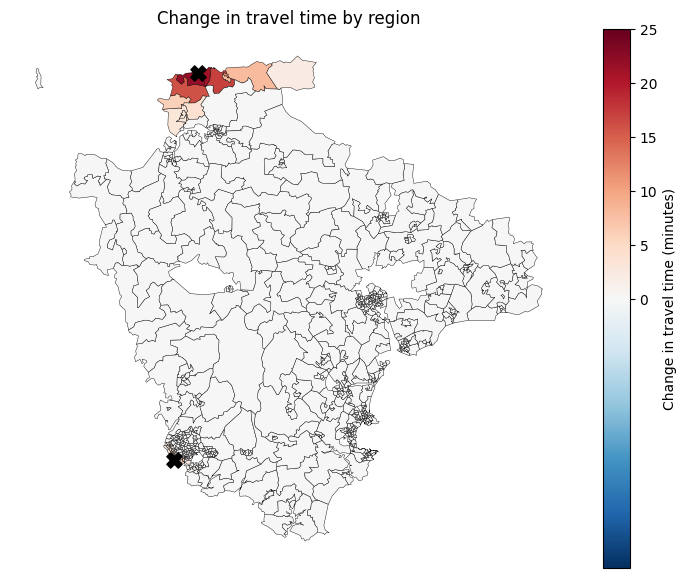

In [26]:
comparator_weighted_average = SolutionComparator(
    baseline, closures_weighted_average,
    labels=("Current (15 sites)", "Best on weighted average"),
    )

comparator_weighted_average.plot_population_impact_map(show_sites="closed");

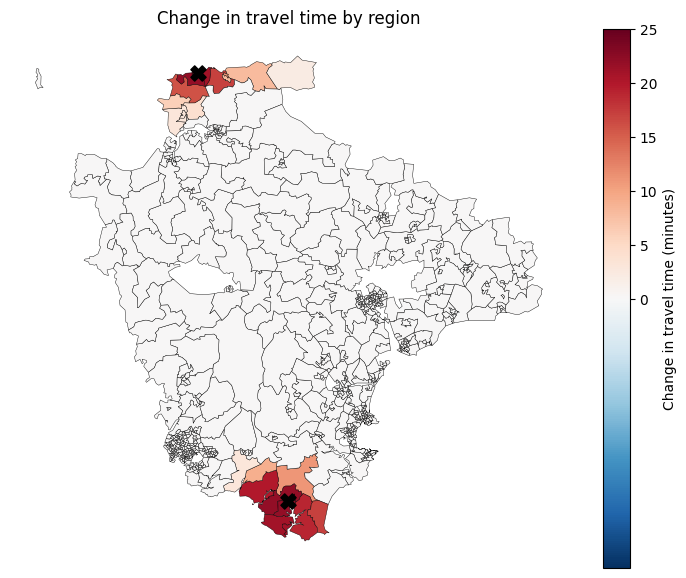

In [27]:
comparator_fewest_affected = SolutionComparator(
    baseline, closures_fewest_affected,
    labels=("Current (15 sites)", "Fewest people affected"),
    )

comparator_fewest_affected.plot_population_impact_map(show_sites="closed");

### Does the choice fall differently across deprivation bands?

Because we registered IMD decile at the top, we can put that difference on a chart rather than leaving it in a sentence. `proportion_of_band_worsened` is the share of each band's *own* population who got a longer journey, which is the comparable figure -- a raw headcount would make a smaller band look less affected simply for being smaller.

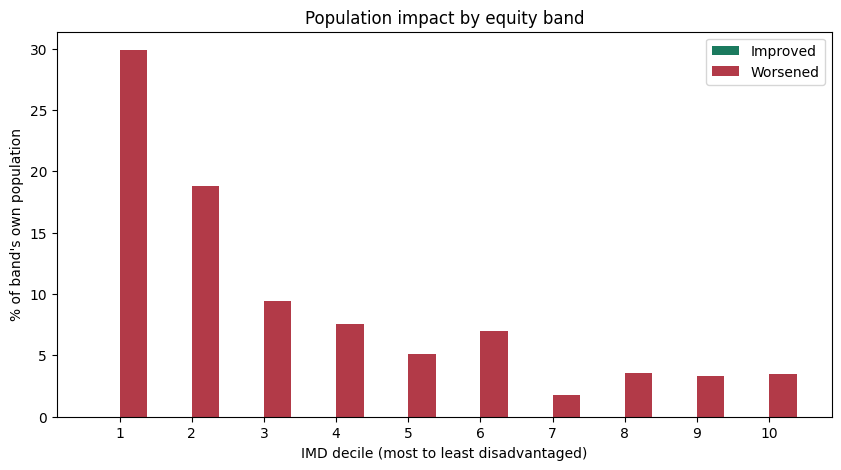

In [28]:
comparator_weighted_average.plot_population_impact_by_equity_group();

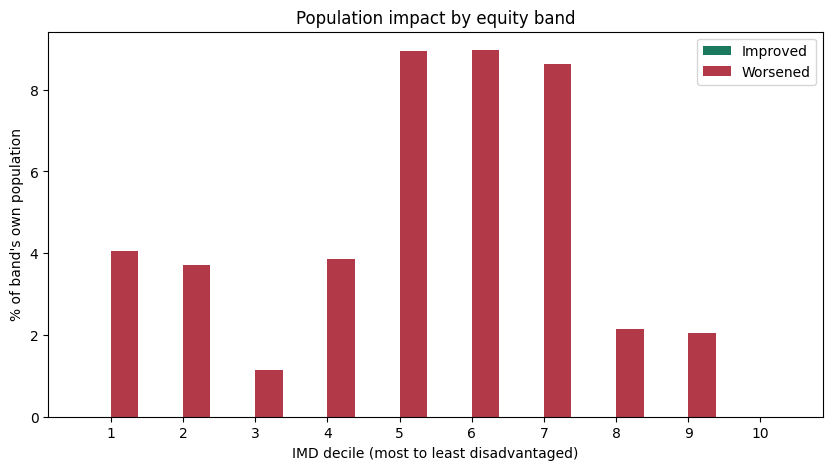

In [29]:
comparator_fewest_affected.plot_population_impact_by_equity_group();

## Where next

`rank_on` handles the case where you know which single metric you care about. Two other examples cover what to do when you care about several at once, and neither is a substitute for the other:

- [Multiobjective optimisation with weights](../multiobjective_optimisation_weights/index.ipynb) -- combining measures into a single blended score, and how demand weighting already does a version of this.
- [Multiobjective optimisation with Pareto fronts](../multiobjective_optimisation_pareto/index.ipynb) -- surfacing the set of solutions where you can't improve one measure without giving up another, rather than picking weights and hoping. When two metrics genuinely pull in opposite directions (as `demand_worsened` and `mean_increase_among_worsened` do above), this is usually the more defensible answer: it shows a decision-maker the trade-off instead of burying it in a ratio someone had to invent.

Related reading:

- [Population impact vs baseline](../population_impact/index.ipynb) -- where the impact metrics used in part 2 come from, and why a region-wide average dilutes local effects.
- [Site closure problems](../site_closures/index.ipynb) -- the closure workflow in full, including reallocation matrices and board-paper summaries.
- [Equity](../equity/index.ipynb) -- the equity metrics behind `inter_tertile_ratio`.